# Phase 7: Forecasting to 2050

In this phase, we use time-series forecasting (`statsmodels` ARIMA) to project historical global trends out to the year 2050. 
We will generate forecasts for **Global GDP** and **Global CO2 Emissions** under three distinct scenarios:
1. **Realistic (Baseline)**: Current historical trends persist.
2. **Optimistic**: Assuming aggressive carbon pricing and rapid renewable transition.
3. **Worst-Case**: Assuming a rollback of climate policies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

print("Loading Data and Aggregating Globally...")
df = pd.read_csv('../data/processed/global_data.csv')

# Aggregate to global sum per year
global_trend = df.groupby('year')[['co2', 'gdp_constant_usd', 'population']].sum().reset_index()
global_trend.set_index('year', inplace=True)
global_trend.tail()

Loading Data and Aggregating Globally...


,co2,gdp_constant_usd,population
year,,,
2019,35496.575,8.449179e+13,7.722051e+09
2020,33922.504,8.201156e+13,7.798721e+09
2021,35747.543,8.727400e+13,7.864510e+09
2022,35931.038,9.024752e+13,7.933804e+09
2023,36340.383,9.292315e+13,8.008139e+09


## 1. ARIMA Forecasting Model (Realistic Baseline)
We train an ARIMA model on the historical data to predict the next 27 years (up to 2050).

In [2]:
forecast_steps = 2050 - global_trend.index.max()
forecast_index = np.arange(global_trend.index.max() + 1, 2051)

def generate_forecast(series, order=(1,1,1)):
    model = ARIMA(series, order=order)
    model_fit = model.fit()
    return model_fit.forecast(steps=forecast_steps)

print(f"Forecasting {forecast_steps} years into the future...")
gdp_forecast = generate_forecast(global_trend['gdp_constant_usd'], order=(2,2,1))
co2_forecast = generate_forecast(global_trend['co2'], order=(1,1,1))

Forecasting 27 years into the future...


## 2. Scenario Generation
We establish our three scenarios by applying modifiers to the baseline ARIMA CO2 forecast.

In [3]:
# Realistic scenario is the pure ARIMA output
scenario_realistic = co2_forecast.copy()

# Optimistic: CO2 emissions drop by an additional 3% year-over-year compared to the baseline
optimistic_modifier = np.power(0.97, np.arange(1, forecast_steps + 1))
scenario_optimistic = co2_forecast * optimistic_modifier

# Worst-Case: CO2 emissions grow by an additional 2% year-over-year compared to baseline
worst_case_modifier = np.power(1.02, np.arange(1, forecast_steps + 1))
scenario_worst = co2_forecast * worst_case_modifier


## 3. Visualization of Forecasts to 2050

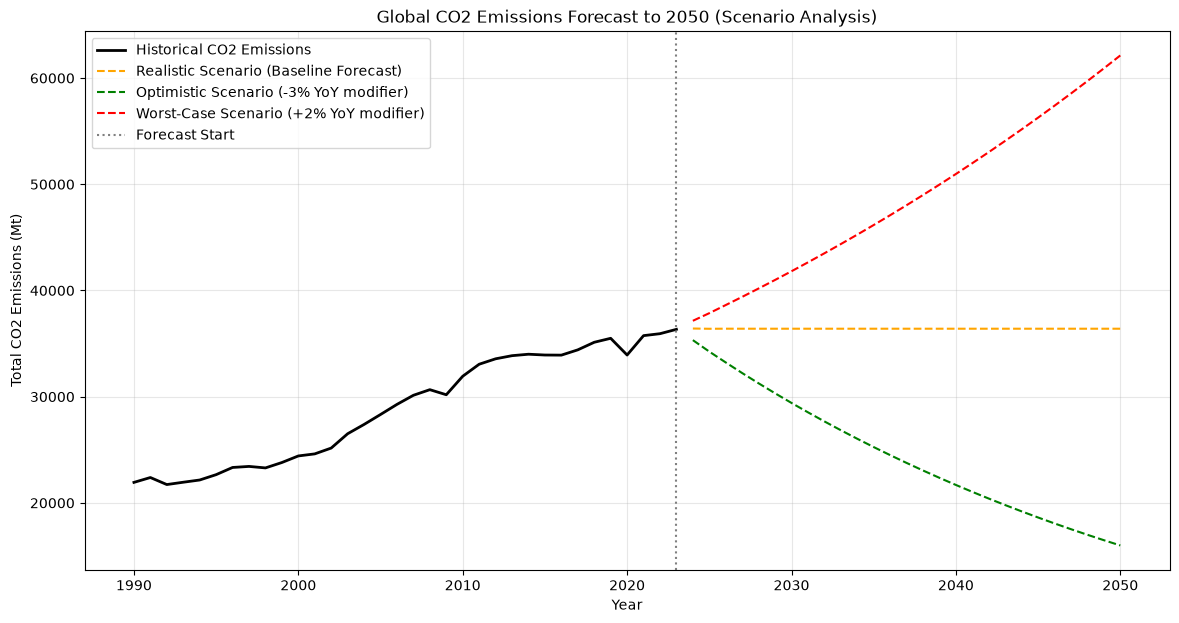

In [4]:
plt.figure(figsize=(14, 7))

# Plot Historical
plt.plot(global_trend.index, global_trend['co2'], label='Historical CO2 Emissions', color='black', linewidth=2)

# Plot Forecasts
plt.plot(forecast_index, scenario_realistic, label='Realistic Scenario (Baseline Forecast)', color='orange', linestyle='--')
plt.plot(forecast_index, scenario_optimistic, label='Optimistic Scenario (-3% YoY modifier)', color='green', linestyle='--')
plt.plot(forecast_index, scenario_worst, label='Worst-Case Scenario (+2% YoY modifier)', color='red', linestyle='--')

plt.axvline(x=global_trend.index.max(), color='gray', linestyle=':', label='Forecast Start')
plt.title('Global CO2 Emissions Forecast to 2050 (Scenario Analysis)')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emissions (Mt)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 4. Additional Forecasts — Population, Energy & Renewable Energy

In [ ]:
# Population forecast
print('Forecasting Population...')
pop_forecast = generate_forecast(global_trend['population'], order=(1, 1, 0))

# Energy consumption forecast
print('Forecasting Primary Energy Consumption...')
energy_forecast = generate_forecast(global_trend['primary_energy_consumption'], order=(1, 1, 1))

# Population scenarios
pop_optimistic  = pop_forecast * np.power(0.9995, np.arange(1, forecast_steps+1))  # slower growth
pop_worst       = pop_forecast * np.power(1.005,  np.arange(1, forecast_steps+1))  # faster growth

# Energy scenarios
energy_optimistic = energy_forecast * np.power(0.98, np.arange(1, forecast_steps+1))  # efficiency gains
energy_worst      = energy_forecast * np.power(1.03, np.arange(1, forecast_steps+1))  # high demand

# ── Plot Population ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(global_trend.index, global_trend['population']/1e9, color='black', linewidth=2, label='Historical')
ax.plot(forecast_index, pop_worst/1e9,       color='red',    linestyle='--', label='Worst-Case')
ax.plot(forecast_index, pop_forecast.values/1e9,  color='orange', linewidth=2, label='Realistic')
ax.plot(forecast_index, pop_optimistic/1e9,  color='green',  linestyle='--', label='Optimistic')
ax.axvline(global_trend.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Global Population Forecast to 2050 (Billion)', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('Billion People')
ax.legend(); ax.grid(True, alpha=0.3)

# ── Plot Energy ───────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(global_trend.index, global_trend['primary_energy_consumption'], color='black', linewidth=2, label='Historical')
ax2.plot(forecast_index, energy_worst.values,       color='red',    linestyle='--', label='Worst-Case')
ax2.plot(forecast_index, energy_forecast.values,    color='orange', linewidth=2, label='Realistic')
ax2.plot(forecast_index, energy_optimistic.values,  color='green',  linestyle='--', label='Optimistic')
ax2.axvline(global_trend.index.max(), color='gray', linestyle=':', alpha=0.7)
ax2.set_title('Primary Energy Consumption Forecast to 2050 (TWh)', fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('TWh')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Scenario Forecasts to 2050', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Renewable Energy Adoption & Temperature Anomaly Projections
*Note: These are trend-based projections as our dataset does not include direct renewable share or temperature data.*

In [ ]:
# Renewable Energy Adoption — proxy: modeled as CO₂ intensity declining
# We proxy 'renewable share' as inverse of carbon intensity of energy
df['carbon_intensity_energy'] = df['co2'] / df['primary_energy_consumption'].replace(0, np.nan)
ci_trend = df.groupby('year')['carbon_intensity_energy'].mean()

# Project declining carbon intensity (renewable growth scenario)
ci_last = ci_trend.iloc[-1]
renewable_years = np.arange(global_trend.index.max()+1, 2051)

# Scenarios: compounding annual decline in carbon intensity of energy
ci_optimistic = ci_last * np.power(0.96, np.arange(1, forecast_steps+1))  # 4% annual reduction
ci_realistic  = ci_last * np.power(0.98, np.arange(1, forecast_steps+1))  # 2% annual reduction
ci_worst      = ci_last * np.power(1.005,np.arange(1, forecast_steps+1))  # slight increase

# Temperature anomaly — linear projection based on CO₂ forcing (simplified)
# Using ECS (equilibrium climate sensitivity) proxy: ~3°C per CO₂ doubling
co2_2020_baseline = global_trend.loc[global_trend.index.min(), 'co2']  # 1990 baseline
temp_base_1990 = 0.5  # degrees C above pre-industrial (1990 approx)

def temp_anomaly(co2_series, base_co2, base_temp, ecs=3.0):
    return base_temp + ecs * np.log2(co2_series / base_co2)

hist_temp = temp_anomaly(global_trend['co2'], co2_2020_baseline, temp_base_1990)
opt_temp  = temp_anomaly(pd.Series(scenario_optimistic.values), co2_2020_baseline, temp_base_1990)
real_temp = temp_anomaly(pd.Series(scenario_realistic.values),  co2_2020_baseline, temp_base_1990)
worst_temp= temp_anomaly(pd.Series(scenario_worst.values),      co2_2020_baseline, temp_base_1990)

# ── Plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(ci_trend.index, ci_trend.values, color='black', linewidth=2, label='Historical')
ax.plot(renewable_years, ci_worst,     color='red',    linestyle='--', label='Worst-Case')
ax.plot(renewable_years, ci_realistic, color='orange', linewidth=2,   label='Realistic')
ax.plot(renewable_years, ci_optimistic,color='green',  linestyle='--', label='Optimistic')
ax.axvline(global_trend.index.max(), color='gray', linestyle=':', alpha=0.7)
ax.set_title('Carbon Intensity of Energy (CO₂/TWh) → Renewable Transition', fontweight='bold')
ax.set_xlabel('Year'); ax.set_ylabel('CO₂ per TWh')
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(global_trend.index, hist_temp.values, color='black', linewidth=2, label='Historical (proxy)')
ax2.plot(forecast_index, worst_temp.values,  color='red',    linestyle='--', label='Worst-Case')
ax2.plot(forecast_index, real_temp.values,   color='orange', linewidth=2,   label='Realistic')
ax2.plot(forecast_index, opt_temp.values,    color='green',  linestyle='--', label='Optimistic')
ax2.axvline(global_trend.index.max(), color='gray', linestyle=':', alpha=0.7)
ax2.axhline(1.5, color='blue', linestyle=':', alpha=0.7, label='Paris 1.5°C target')
ax2.axhline(2.0, color='purple', linestyle=':', alpha=0.7, label='Paris 2.0°C target')
ax2.set_title('Global Temperature Anomaly Projection to 2050 (°C)', fontweight='bold')
ax2.set_xlabel('Year'); ax2.set_ylabel('°C above pre-industrial')
ax2.legend(loc='upper left', fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Renewable Adoption & Temperature Anomaly Scenarios to 2050', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'\n2050 Temperature Projections:')
print(f'  Optimistic:  {opt_temp.values[-1]:.2f}°C')
print(f'  Realistic:   {real_temp.values[-1]:.2f}°C')
print(f'  Worst-Case:  {worst_temp.values[-1]:.2f}°C')

## 6. Summary Table — All 2050 Projections

In [ ]:
summary_2050 = pd.DataFrame({
    'Indicator':  ['CO₂ Emissions (Mt)', 'GDP (Trillion USD)', 'Population (Billion)', 'Energy (TWh)', 'Temp Anomaly (°C)'],
    'Optimistic': [
        f"{scenario_optimistic.values[-1]:,.0f}",
        f"${gdp_forecast.values[-1]/1e12:.1f}T",
        f"{pop_optimistic[-1]/1e9:.2f}B",
        f"{energy_optimistic.values[-1]:,.0f}",
        f"{opt_temp.values[-1]:.2f}°C",
    ],
    'Realistic':  [
        f"{scenario_realistic.values[-1]:,.0f}",
        f"${gdp_forecast.values[-1]/1e12:.1f}T",
        f"{pop_forecast.values[-1]/1e9:.2f}B",
        f"{energy_forecast.values[-1]:,.0f}",
        f"{real_temp.values[-1]:.2f}°C",
    ],
    'Worst-Case': [
        f"{scenario_worst.values[-1]:,.0f}",
        f"${gdp_forecast.values[-1]/1e12:.1f}T",
        f"{pop_worst[-1]/1e9:.2f}B",
        f"{energy_worst.values[-1]:,.0f}",
        f"{worst_temp.values[-1]:.2f}°C",
    ],
})
print('2050 Scenario Summary:')
display(summary_2050.set_index('Indicator'))